In [1]:
data = [41.7, 36.7, 45.6, 31.0, 38.9, 28.3, 23.7, 54.5, 31.6, 26.1, 50.4, 45.0, 53.5, 50.1, 29.7, 40.9, 32.4, 45.0, 35.6, 25.6, 55.3, 33.1, 25.6, 40.2, 32.2, 43.2, 25.1, 29.9, 52.7, 18.6, 35.3, 38.1, 29.4, 32.1, 43.0, 23.0, 34.1, 28.8, 31.6, 40.8, 32.7, 43.0, 41.7, 41.7, 28.3, 23.1, 18.2, 23.5, 30.3, 36.2, 34.9, 41.0, 54.3, 33.3, 39.3, 12.8, 20.6, 22.6, 26.1, 16.8]

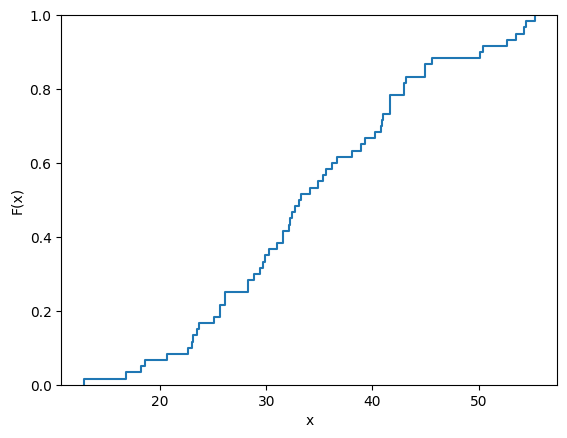

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.ecdfplot(data)
plt.ylabel("F(x)")
plt.xlabel("x")
plt.show()

In [3]:
import numpy as np
from scipy import stats

mean = np.mean(data)

# Исправленная выборочная дисперсия (ddof=1 для деления на n-1)
variance = np.var(data, ddof=1)

# Мода (возвращает самое частое значение)
mode_res = stats.mode(data, keepdims=True)
mode = mode_res.mode[0]

# Медиана
median = np.median(data)

# Коэффициент асимметрии (skewness)
skewness = stats.skew(data, bias=False)

# Коэффициент эксцесса (kurtosis) - возвращает избыточный эксцесс
kurt = stats.kurtosis(data, bias=False)

print(f"--- Результаты расчетов ---")
print(f"Выборочное среднее: {mean:.4f} {sum(data)/len(data)}")
print(f"Исправленная дисперсия: {variance:.4f}")
print(f"Мода: {mode}")
print(f"Медиана: {median}")
print(f"Асимметрия: {skewness:.4f}")
print(f"Эксцесс: {kurt:.4f}")

--- Результаты расчетов ---
Выборочное среднее: 34.6467 34.64666666666667
Исправленная дисперсия: 103.8222
Мода: 41.7
Медиана: 33.2
Асимметрия: 0.1984
Эксцесс: -0.4811


In [4]:
import math
import pandas as pd

n = len(data)
x_min = np.min(data)
x_max = np.max(data)

k = math.ceil(1 + 3.322 * math.log10(n))
h = (x_max - x_min) / k
bins = [x_min + i * h for i in range(k + 1)]
counts, _ = np.histogram(data, bins=bins)

intervals = []
midpoints = []
for i in range(k):
    start = bins[i]
    end = bins[i+1]
    intervals.append(f"[{start:.2f}; {end:.2f})")
    midpoints.append((start + end) / 2)

df = pd.DataFrame({
    "Интервал": intervals,
    "Середина (x_i)": midpoints,
    "Частота (n_i)": counts,
    "Относ. частота (w_i)": counts / n
})

print(f"Объем выборки n = {n}")
print(f"Шаг (h) = {h:.2f}")
print("\nИнтервальный статистический ряд:")
print(df.to_string(index=False))

Объем выборки n = 60
Шаг (h) = 6.07

Интервальный статистический ряд:
      Интервал  Середина (x_i)  Частота (n_i)  Относ. частота (w_i)
[12.80; 18.87)       15.835714              4              0.066667
[18.87; 24.94)       21.907143              6              0.100000
[24.94; 31.01)       27.978571             13              0.216667
[31.01; 37.09)       34.050000             14              0.233333
[37.09; 43.16)       40.121429             12              0.200000
[43.16; 49.23)       46.192857              4              0.066667
[49.23; 55.30)       52.264286              7              0.116667


C:\Users\admin\AppData\Local\Temp\ipykernel_12940\723179724.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


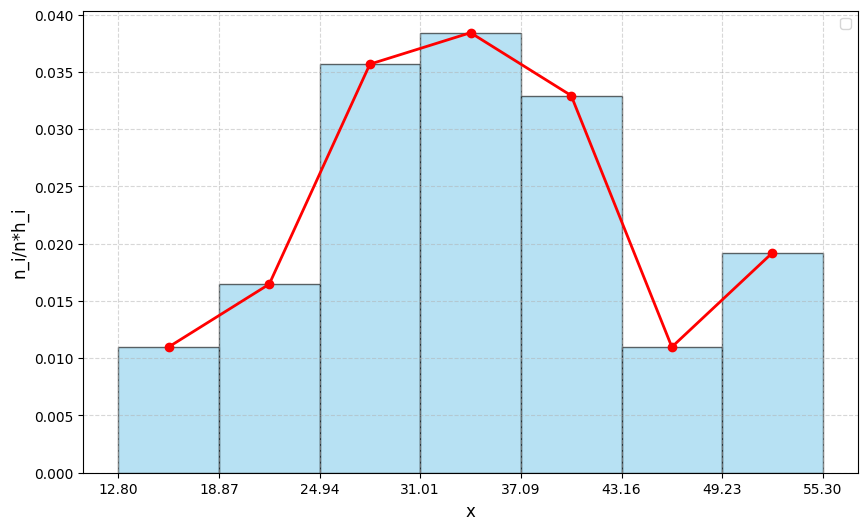

In [5]:
import matplotlib.pyplot as plt
import numpy as np

frequencies, bins = np.histogram(data, bins = 7)

# 1. Расчет необходимых величин
n = np.sum(frequencies)                # Объем выборки
w = frequencies / n                    # Относительные частоты (w_i)
h = bins[1] - bins[0]                  # Ширина интервала (шаг)
densities = w / h                      # Плотность относительной частоты (для гистограммы)
midpoints = (bins[:-1] + bins[1:]) / 2 # Середины интервалов (для полигона)

# 2. Создание графиков
plt.figure(figsize=(10, 6))

# Гистограмма относительных частот
# Высота столбиков в гистограмме относительных частот — это w_i / h
plt.bar(midpoints, densities, width=h, color='skyblue', edgecolor='black', alpha=0.6)

plt.plot(midpoints, densities, color='red', marker='o', linewidth=2)

plt.xlabel('x', fontsize=12)
plt.ylabel('n_i/n*h_i', fontsize=12)
plt.xticks(bins)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()